# Lab 6: RANSAC and Hough Transform
## **NAME**: Vedant Sinha

## **Student ID**: 100420615

⚠️ **Submission Requirement:**  
When submitting, (1) please **export your Jupyter Notebook as a PDF (including all execution outputs)** and submit it, (2) **along with the `.ipynb` source file**. Submissions that do not follow this rule **will receive a grade penalty**.

Each blank to be filled is marked with [Grading Point *].

Complete the implementation below and submit this notebook with your own result by Oct 21 23:59.

## NOTE: Problems below are mostly coding excersices where you should implement and/or test different standard methods for model fitting on examples with synthetic data. The problems below were primarily designed to help the students learn the basics of model parameter estimation in a much more basic context - simple line models and 2D data points (synthetic).
### While the provided initial notebook shows synthetic and real examples of 2D data points for line fitting, you might need to restart the nootebook (Kernel->Restart and Clear Output).

## Problem 1: least-squares and line fitting in 2D (synthetic data without outliers)
### Complete implementation of function $estimate$ of class $LeastSquareLine$ in the second cell below. It should update line parameters $a$ and $b$ correpsonding to line model $y=ax+b$. You can use either SVD of matrix $A$ or inverse of matrix $A^T A$, as mentioned in class. NOTE: several cells below test your code.

In [ ]:
%matplotlib inline

import numpy as np
import numpy.linalg as la
import matplotlib
import matplotlib.pyplot as plt
from skimage.measure import ransac

#### TO IMPLEMENT: complete (fix) the code in the following cell. Note that solution has 2-3 lines. You can use $svd$ function in $la$ and/or standard matrix operations from $np$.

In [9]:
class LeastSquareLine:

    def __init__(self):
        self.a = 0.0
        self.b = 0.0

    def estimate(self, points2D):
        B = points2D[:,1]
        A = np.copy(points2D)
        A[:,1] = 1.0

        # Vector B and matrix A are already defined. Change code below  [Grading Point 1]
        U, S, Vt = la.svd(A, full_matrices=False)
        self.a, self.b = Vt.T @ ((U.T @ B) / S)
        return True

    def predict(self, x): return (self.a * x) + self.b

    def predict_y(self, x): return (self.a * x) + self.b

    def residuals(self, points2D):
        return points2D[:,1] - self.predict(points2D[:,0])

    def line_par(self):
        return self.a, self.b

#### Working code below generates (simulates) data points in $R^2$ corresponding to noisy observations of a line.

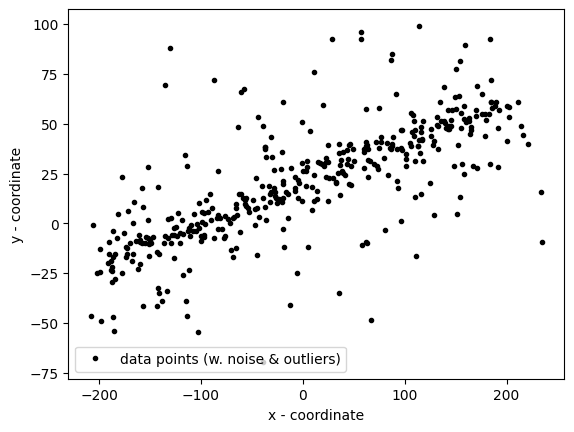

In [ ]:
np.random.seed(seed=1)

# parameters for "true" line y = a*x + b
a, b = 0.2, 20.0

# x-range of points [x1,x2]
x_start, x_end = -200.0, 200.0

# generate "idealized" line points
x = np.arange(x_start,x_end)
y = a * x + b
data = np.column_stack([x, y])    # staking data points into (Nx2) array

# add gaussian pertubations to generate "realistic" data points (noisy line observations)
noise = np.random.normal(size=data.shape) # generating Gaussian noise (variance 1) for each data point (rows in 'data')
data += 5 * noise
data[::2] += 10 * noise[::2]  # every second point adds noise with variance 5
data[::4] += 20 * noise[::4] # every fourth point adds noise with variance 20

# IMPORTANT COMMENT!!!!!!!:
# the data now combines line points with different levels of additive Gaussie noise.
# Consider all these points as noisy inliers.
# Do not consider any of these as outliers. The outliers are added in Problem 4.


fig, ax = plt.subplots()
ax.plot(data[:,0], data[:,1], '.k', label='data points (w. noise & outliers)')
ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')
plt.show()

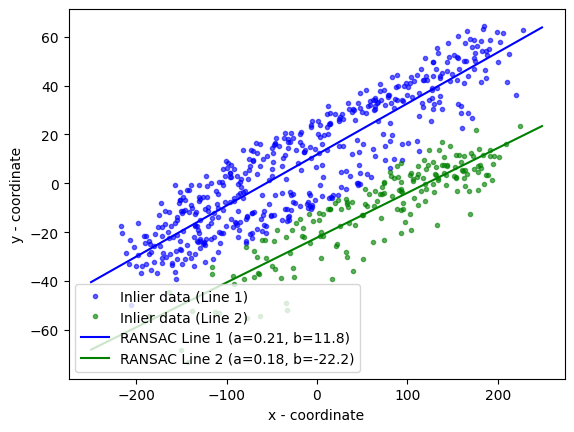

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import ransac

# Re-generate the data with two lines and outliers
# parameters for "true" lines y = a*x + b
a1, b1 = 0.2, 20.0
a2, b2 = 0.1, -10.0

# x-range of points [x1,x2]
x_start, x_end = -200.0, 200.0

# generate "idealized" line points for first line
x = np.arange(x_start,x_end)
y1 = a1 * x + b1
data1 = np.column_stack([x, y1])

# add gaussian pertubations to generate "realistic" line data for first line
noise1 = np.random.normal(size=data1.shape)
data1 += 5 * noise1
data1[::2] += 10 * noise1[::2]
data1[::4] += 20 * noise1[::4]

# generate "idealized" line points for second line
y2 = a2 * x + b2
data2 = np.column_stack([x, y2])

# add gaussian pertubations to generate "realistic" line data for second line
noise2 = np.random.normal(size=data2.shape)
data2 += 5 * noise2
data2[::2] += 10 * noise2[::2]
data2[::4] += 20 * noise2[::4]


data = np.concatenate((data1,data2)) # combining with previous data

# add outliers
faulty = np.array(30 * [(180., -100)])  # (30x2) array containing 30 rows [180,-100]  (points)
faulty += 5 * np.random.normal(size=faulty.shape)  # adding Gaussian noise to these points
# Add outliers to the beginning of the concatenated data
data[:faulty.shape[0]] = faulty


# Sequential RANSAC
all_inliers = np.arange(len(data))
remaining_data = np.copy(data)
detected_lines = []

# Find the first line
model_robust1, inliers1_indices = ransac(remaining_data, LeastSquareLine, min_samples=2, residual_threshold=20, max_trials=100)
detected_lines.append(model_robust1)

# Remove the inliers of the first line from the remaining data
remaining_data = np.delete(remaining_data, inliers1_indices, axis=0)
remaining_inliers_indices = np.delete(all_inliers, inliers1_indices)


# Find the second line from the remaining data
model_robust2, inliers2_indices = ransac(remaining_data, LeastSquareLine, min_samples=2, residual_threshold=20, max_trials=100)
detected_lines.append(model_robust2)

# Get the original indices of the inliers for the second line
inliers2_original_indices = remaining_inliers_indices[inliers2_indices]


# Plotting the results
fig, ax = plt.subplots()
ax.plot(data[inliers1_indices, 0], data[inliers1_indices, 1], '.b', alpha=0.6, label='Inlier data (Line 1)')
ax.plot(data[inliers2_original_indices, 0], data[inliers2_original_indices, 1], '.g', alpha=0.6, label='Inlier data (Line 2)')

# Plot the detected lines
line_x = np.arange(-250, 250)
line_y_robust1 = model_robust1.predict_y(line_x)
ax.plot(line_x, line_y_robust1, '-b', label='RANSAC Line 1 (a={:4.2f}, b={:4.1f})'.format(*model_robust1.line_par()))

line_y_robust2 = model_robust2.predict_y(line_x)
ax.plot(line_x, line_y_robust2, '-g', label='RANSAC Line 2 (a={:4.2f}, b={:4.1f})'.format(*model_robust2.line_par()))


ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')
plt.show()

#### Use the following code-cell to test your implementation of class $LeastSquareLine$ in Problem 3 for line fitting when observed data is noisy. The estimated line is displayed in the cell above.  Note that the initial result shown in Fig.1 of the provided notebook corresponds to the line $a=0,b=0$ returned by initial code for $LeastSquareLine$.  Your correct solution for $LeastSquareLine$ should return a line very close to the known (ground-truth) line model.

True


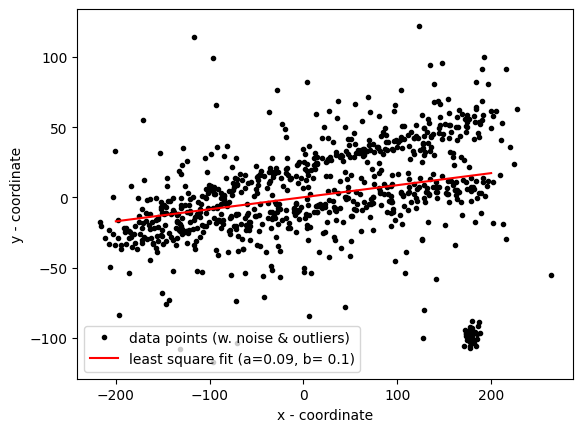

In [19]:
LSline = LeastSquareLine() # uses class implemented in Problem 2
print (LSline.estimate(data))
a_ls, b_ls = LSline.line_par()

# visualizing estimated line
fig, ax = plt.subplots()
ax.plot(data[:,0], data[:,1], '.k', label='data points (w. noise & outliers)')
ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')

ends = np.array([x_start,x_end])
ax.plot(ends, LSline.predict(ends), '-r', label='least square fit (a={:4.2f}, b={:4.1f})'.format(a_ls,b_ls))
ax.legend(loc='lower left')
plt.show()

## Problem 2: RANSAC for robust line fitting in 2D (synthetic data with outliers)

#### Working code in the cell below corrupts data with outliers.

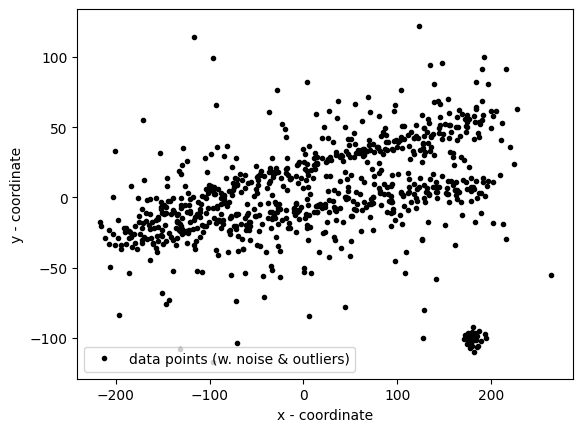

In [20]:
# add outliers
faulty = np.array(30 * [(180., -100)])  # (30x2) array containing 30 rows [180,-100]  (points)
faulty += 5 * np.random.normal(size=faulty.shape)  # adding Gaussian noise to these points
data[:faulty.shape[0]] = faulty   # replacing the first 30 points in data with faulty (outliers)


fig, ax = plt.subplots()
ax.plot(data[:,0], data[:,1], '.k', label='data points (w. noise & outliers)')
ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')
plt.show()

### NOTE: As clear from the code for data simulation, (creation of) outliers has nothing to do with the line. In contrast, all other points originate from some points on the true (perfect) line, see Probelm 1. The added Gaussian errors (large or small) simulate complex noise that commonly happens between true (but unknown) model and its real observations (data). The whole point of "model fitting" is to estimate (or restore) a "model" (e.g. line parameters) from its noisy observations (data). If data has no noise, it is trivial, e.g. only two line points would be enough to compute the line parameters exactly. In the presence of noise, one can use methods like least-squres to approximately estimate a line (parameters minimizing the loss functing summing squared $L_2$ errors), see Problem 1. However, if data is corrupted by outliers that have nothing to do with the model, as in Problem 2, more robust model fitting methods are needed, e.g. RANSAC.

#### The code below uses your implementation of class $LeastSquareLine$ from Probelm 1 for least-square line fitting when the data is corrupted with outliers. The estimated line is displayed in the cell above. Observe the differences with the result in Problem 1.

True


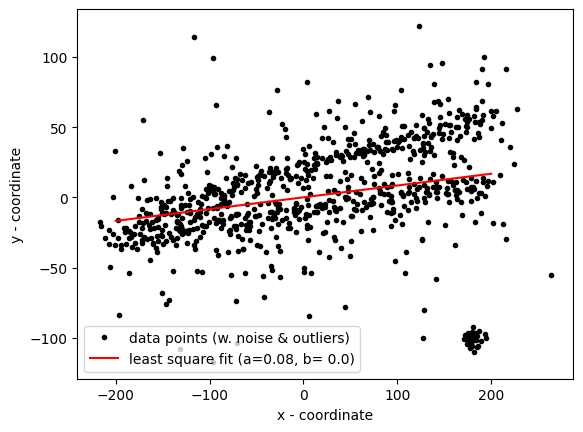

In [21]:
LSline = LeastSquareLine() # uses class implemented in Problem 2
print (LSline.estimate(data))
a_ls, b_ls = LSline.line_par()

# visualizing estimated line
fig, ax = plt.subplots()
ax.plot(data[:,0], data[:,1], '.k', label='data points (w. noise & outliers)')
ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')

ends = np.array([x_start,x_end])
ax.plot(ends, LSline.predict(ends), '-r', label='least square fit (a={:4.2f}, b={:4.1f})'.format(a_ls,b_ls))
ax.legend(loc='lower left')
plt.show()

### (part a) Assume that a set of $N=100$ points in $2D$ includes $N_i=20$ inliers for one line and $N_o=80$ outliers. What is the least number of times one should sample a random pair of points from the set to get probability $p\geq 0.95$ that in at least one of the sampled pairs both points are inliers? Derive a general formula and compute a numerical answer for the specified numbers.

Solution Guide:
*   Derive the general formula for computing the minimum number of RANSAC iterations, k. Your derivation should express k in terms of the desired success probability p, the inlier ratio w, and the number of sample points n.

*   Using this formula, calculate the numerical value of k for the case specified in part (a). Show your work.

Solution:  [Grading Point 2]

P = 1 - (1-w^n)^k
Then solving for K:
k >= ln(1−p)/ln(1−w^n)

Then plugging in our values we get: k >= ln(0.05)/ln(0.96) = 74 Trails
	​

	​


### (part b) Using the knowledge of the number of inliers/outliers in the example at the beginning of Problem 2, estimate the minimum number of sampled pairs needed to get RANSAC to "succeed" (to get at least one pair of inliers) with $p\geq 0.95$. Use your formula in part (a). Show your numbers in the cell below. Then, use your estimate as a value of parameter $max\text{_}trials$  inside function $ransac$ in the code cell below and test it.  You should also change $residual\text{_}threshold$ according to the noise level for inliers in the example. NOTE: the result is displayed in the same figure at the beginning of Problem 2.


Solution Guide:

*   In the "Your estimates" cell, provide your estimated values for the RANSAC parameters:


    *   Calculate the required max_trials for the given dataset using your formula from part (a).
    *   Propose and justify a suitable residual_threshold based on the noise characteristics of the inlier data.


*   In the subsequent code cell, modify the call to the ransac() function by implementing your estimated max_trials and residual_threshold values.


Your estimates: [Grading Point 3]

Choose: max_trials at least 74 so I will choose 100 to be sure

Residual threshold: the inlier scatter in y is roughly on the order of ~6–10 units from the plot/noise settings, so use a vertical residual threshold around 15

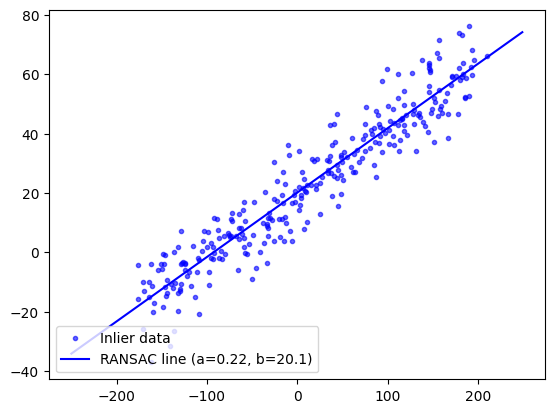

In [15]:
import numpy.linalg as la
import matplotlib.pyplot as plt
# add outliers
faulty = np.array(30 * [(180., -100)])  # (30x2) array containing 30 rows [180,-100]  (points)
faulty += 5 * np.random.normal(size=faulty.shape)  # adding Gaussian noise to these points

# parameters for "true" line y = a*x + b
a, b = 0.2, 20.0

# x-range of points [x1,x2]
x_start, x_end = -200.0, 200.0

# generate "idealized" line points
x = np.arange(x_start,x_end)
y = a * x + b
data = np.column_stack([x, y])    # staking data points into (Nx2) array

# add gaussian pertubations to generate "realistic" data points (noisy line observations)
noise = np.random.normal(size=data.shape) # generating Gaussian noise (variance 1) for each data point (rows in 'data')
data += 5 * noise
data[::2] += 10 * noise[::2]  # every second point adds noise with variance 5
data[::4] += 20 * noise[::4] # every fourth point adds noise with variance 20

data[:faulty.shape[0]] = faulty   # replacing the first 30 points in data with faulty (outliers)


# robustly fit line using RANSAC algorithm
model_robust, inliers = ransac(data, LeastSquareLine, min_samples=2, residual_threshold=20, max_trials=100) # [Grading Point 4]
a_rs, b_rs = model_robust.line_par()

# generate coordinates of estimated models
line_x = np.arange(-250, 250)
line_y_robust = model_robust.predict_y(line_x)

fig, ax = plt.subplots()
ax.plot(data[inliers, 0], data[inliers, 1], '.b', alpha=0.6, label='Inlier data')
ax.plot(line_x, line_y_robust, '-b', label='RANSAC line (a={:4.2f}, b={:4.1f})'.format(a_rs,b_rs))
ax.legend(loc='lower left')
plt.show()

## Problem 3: sequential RANSAC for robust multi-line fitting (synthetic data)

#### Adding data points supporting one more line

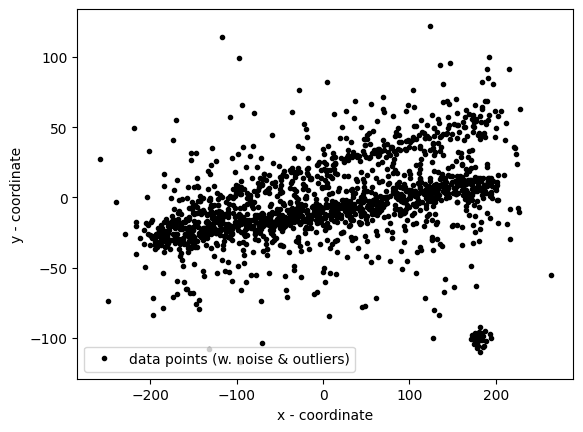

In [24]:
# parameters for "true" lines y = a*x + b
a2, b2 = 0.1, -10.0

# generate "idealized" line points
y2 = a2 * x + b2
data2 = np.column_stack([x, y2])    # staking data points into (Nx2) array

# add gaussian pertubations to generate "realistic" line data
noise = np.random.normal(size=data2.shape) # generating Gaussian noise (variance 1) for each data point (rows in 'data')
data2+= 5 * noise
data2[::2] += 10 * noise[::2]  # every second point adds noise with variance 5
data2[::4] += 20 * noise[::4] # every fourth point adds noise with variance 20

data = np.concatenate((data,data2)) # combining with previous data

fig, ax = plt.subplots()
ax.plot(data[:,0], data[:,1], '.k', label='data points (w. noise & outliers)')
ax.set_xlabel('x - coordinate')
ax.set_ylabel('y - coordinate')
ax.legend(loc='lower left')
plt.show()

### Write code below using sequential RANSAC to detect two lines in the data above. Your lines should be displayed in the figure above (in Problem 3).


Solution Guide:

*   In the final code cell, write a script to implement the sequential RANSAC algorithm to detect both lines in the data.

*   Your implementation should:

    1.   Run RANSAC to find the first line and its corresponding inliers.

    2.   Remove the identified inliers from the dataset.

    3. Remove the identified inliers from the dataset.

*   Produce a single plot that visualizes the final results, including the two detected lines, their respective inlier sets, and any remaining points classified as outliers.


[Grading Point 5]

## Problem 4: Line Detection using the Hough Transform

**4.1 Theoretical Background**

The Hough Transform is a powerful feature extraction technique used to find shapes like lines or circles within an image. It is a "Hypothesize and test" method that uses a **voting mechanism** in a **parameter space** (also called Hough space).

For line detection, instead of the Cartesian form `y = mx + b` (which has an unbounded parameter space), the polar representation is used:

$$\rho = x \cos(\theta) + y \sin(\theta)$$

Here, `ρ` (rho) is the perpendicular distance from the origin to the line, and `θ` (theta) is the angle of that perpendicular line. A point `(x, y)` in the image space corresponds to a sinusoidal curve in the `(ρ, θ)` parameter space. Points that are collinear in the image space will have their corresponding curves intersect at a single point in the Hough space. Our task is to find these intersection points.

This problem will require you to implement a basic Hough Transform function and use it to detect lines in both a synthetic and a real image.


**4.2 Task: Implement the Hough Transform Function**

Create a function `hough_line(edge_image)` that takes a binary edge image as input and returns a 2D accumulator array representing the Hough space.

**Function Steps:**
1.  Get the height and width of the input image.
2.  Calculate the maximum possible value for `ρ`, which is the length of the image diagonal.
3.  Define the ranges and resolutions for `θ` and `ρ`. The range for `θ` is `[-90°, 90°]`, and for `ρ` is `[-ρ_max, ρ_max]`.
4.  Create a 2D `accumulator` grid based on the ranges of `θ` and `ρ`, and initialize it to zeros.
5.  Find the coordinates of all edge points (pixels with a non-zero value).
6.  Iterate through each edge point `(y, x)`:
    * Iterate through all possible `θ` values.
    * Calculate the corresponding `ρ` value using the formula `ρ = x cos(θ) + y sin(θ)`.
    * Increment the accumulator cell corresponding to the calculated `(ρ, θ)` pair (this is the "vote").
7.  Return the accumulator array.

Please complete the code below:

In [25]:
import numpy as np
import imageio.v2 as imageio
from skimage.transform import hough_line, hough_line_peaks
from skimage.feature import canny
from skimage.draw import line
import matplotlib.pyplot as plt

def hough_line_transform(edge_image):
    """
    Applies the Hough Transform for line detection on an edge image.

    Parameters:
    edge_image (numpy.ndarray): A binary image resulting from an edge detector.

    Returns:
    accumulator (numpy.ndarray): The 2D accumulator array.
    thetas (numpy.ndarray): The array of theta values.
    rhos (numpy.ndarray): The array of rho values.
    """
    # Image dimensions
    height, width = edge_image.shape

    # Rho and Theta ranges
    max_rho = np.ceil(np.sqrt(height**2 + width**2)).astype(int)
    rhos = np.linspace(-max_rho, max_rho, max_rho * 2)
    thetas = np.deg2rad(np.arange(-90.0, 90.0))

    # Create the accumulator
    accumulator = np.zeros((2 * max_rho, len(thetas)), dtype=np.uint64)

    # Find the coordinates of all edge points
    y_idxs, x_idxs = np.nonzero(edge_image)

    # Vote for each theta for each edge point
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]

        for t_idx in range(len(thetas)):
            # Calculate rho
            theta = thetas[t_idx]
            rho = x * np.cos(theta) + y * np.sin(theta) # [Grading Point 6]

            # Map rho to the accumulator index and vote
            # We need to shift the rho value (which can be negative) to the positive index range of the array
            rho_idx = int(round(rho + max_rho)) # Using round is more accurate
            accumulator[rho_idx, t_idx] += 1 # Cast 1 vote # [Grading Point 7]

    return accumulator, thetas, rhos

**4.3 Task: Apply to a Synthetic Image**

To verify your function, we will first test it on a simple synthetic image. The code below creates a black image with three white lines.

Run your function and display the Hough space accumulator.

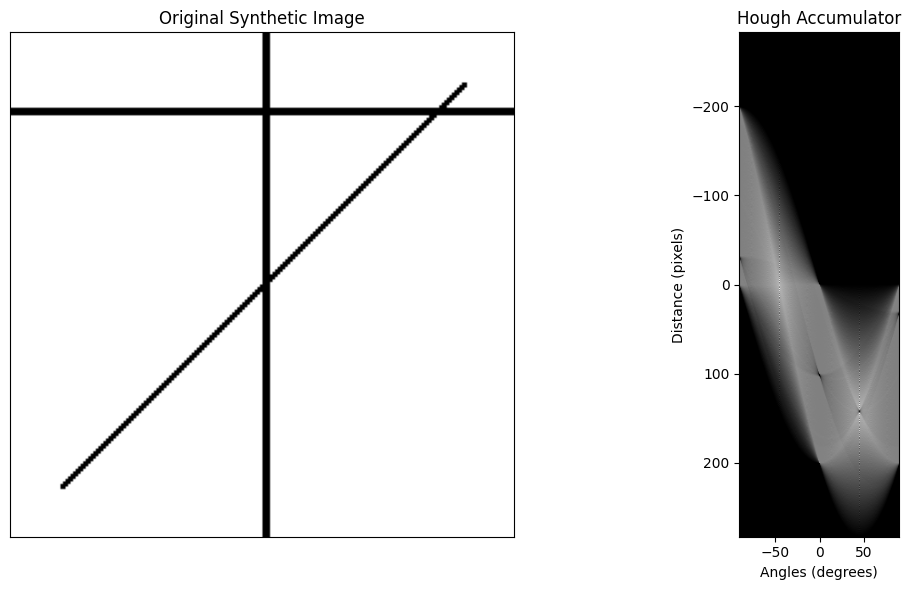

In [26]:
import numpy as np
from skimage.draw import line
import matplotlib.pyplot as plt

# --- Create the synthetic image ---
# Create a 200x200 synthetic image, larger for better visibility
synthetic_image = np.ones((200, 200), dtype=np.uint8) * 255

# Draw a 3-pixel thick horizontal line
synthetic_image[30:33, :] = 0

# Draw a 3-pixel thick vertical line
synthetic_image[:, 100:103] = 0

# Use skimage.draw.line to draw a thick diagonal line
# We achieve thickness by drawing three adjacent parallel lines
rr, cc = line(20, 180, 180, 20)
synthetic_image[rr, cc] = 0
rr, cc = line(21, 180, 180, 21)
synthetic_image[rr, cc] = 0
rr, cc = line(20, 179, 179, 20)
synthetic_image[rr, cc] = 0


# --- Hough Transform ---
# Assume the hough_line_transform function is already defined
accumulator, thetas, rhos = hough_line_transform(synthetic_image) # [Grading Point 8]


# --- Modified Plotting Code ---

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the original image on the first subplot (axes[0])
axes[0].imshow(synthetic_image, cmap='gray')
axes[0].set_title('Original Synthetic Image')
axes[0].axis('image') # Keep the aspect ratio
axes[0].set_xticks([]) # Hide X-axis ticks
axes[0].set_yticks([]) # Hide Y-axis ticks


# Plot the Hough space on the second subplot (axes[1])
axes[1].imshow(accumulator, cmap='gray', extent=[np.rad2deg(thetas[0]), np.rad2deg(thetas[-1]), rhos[-1], rhos[0]])
axes[1].set_title('Hough Accumulator')
axes[1].set_xlabel('Angles (degrees)')
axes[1].set_ylabel('Distance (pixels)')
axes[1].axis('image') # Keep the aspect ratio

# Adjust subplot layout and show the plot
plt.tight_layout()
plt.show()

**4.4 Task: Find Lines in a Real Image**

Now, we will apply the full pipeline to a real image of a building. This requires a complete workflow including preprocessing (Canny edge detection) and post-processing (finding peaks and drawing lines).

Complete and run the following code:

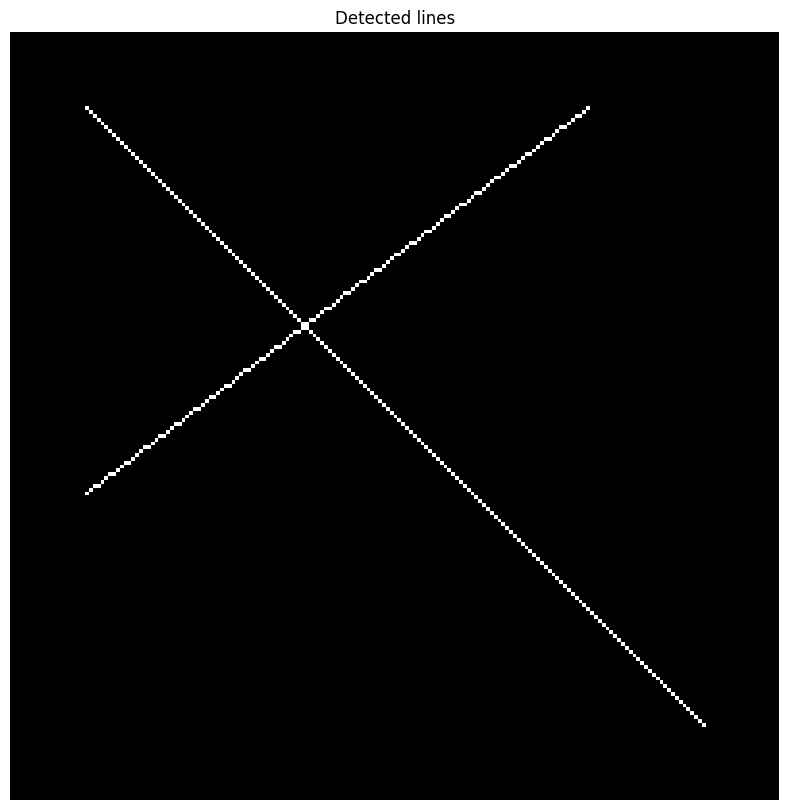

In [27]:
# 1. Load the image and perform Canny edge detection
try:
    image = imageio.imread('ucm2.jpg', pilmode='L')
except (FileNotFoundError, NameError):
    # Fallback if the specific image is not available
    image = np.zeros((200, 200))
    rr, cc = line(20, 20, 180, 180)
    image[rr, cc] = 1
    rr, cc = line(20, 150, 120, 20)
    image[rr, cc] = 1

edges = canny(image, sigma=2, low_threshold=50, high_threshold=150)

# 2. Apply the Hough transform to the edge image
accumulator, thetas, rhos = hough_line_transform(edges) # [Grading Point 9]

# 3. Find peaks in the accumulator
# hough_line_peaks will return the h, theta, d (value, angle, distance) of the most prominent lines
tested_angles = np.rad2deg(thetas)
hspace, angles, dists = hough_line_peaks(accumulator, thetas, rhos, num_peaks=10)

# 4. Plot the detected lines
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(image, cmap=plt.cm.gray)
origin = np.array((0, image.shape[1]))

for _, angle, dist in zip(hspace, angles, dists):
    y0, y1 = (dist - origin * np.cos(angle)) / np.sin(angle)
    ax.plot(origin, (y0, y1), '-r')

ax.set_xlim(origin)
ax.set_ylim((image.shape[0], 0))
ax.set_axis_off()
ax.set_title('Detected lines')
plt.show()